In [23]:
import uproot
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
plt.style.use('belle2')
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
import glob
import os

import joblib

In [24]:
# Function to load and filter data from multiple files
def load_and_filter(file_paths, tree_name, cut_signal):
    branches = ['Dp_isSignal','Dp_M','Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID','etapip_Eta_genMotherPDG',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal', 'rank_Dp_chiProb']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [25]:
# Function to load and filter data from multiple files
def load_and_filter_ds_weight(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal','ds_weight','BDT','Dp_M', 'rank_Dp_chiProb']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [26]:
# # Function to load and filter data from multiple files
# def load_and_filter_test(file_paths, tree_name, cut_signal):
#     branches = ['Dp_M','Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
#                 'Pip_genMotherID', 'etapip_Eta_genMotherID',
#                 'Pip_genMotherPDG', 'etapip_Eta_isSignal', 'bdtg_norm', 'bdtg_weight','Dp_isSignal','bdtg','Pip_charge']
    
#     if isinstance(file_paths, str):
#         file_paths = glob.glob(file_paths)

#     df_list = []
#     for file_path in file_paths:
#         try:
#             df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
#             df_filtered = df.query(cut_signal)
#             df_list.append(df_filtered)
#         except Exception as e:
#             print(f"[Warning] Skipping file {file_path}: {e}")

#     return pd.concat(df_list, ignore_index=True)

In [27]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi_cc/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가
N_signal = len(df_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = "0.77"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# # === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_plus.pkl'")
# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_K_plus.pkl'


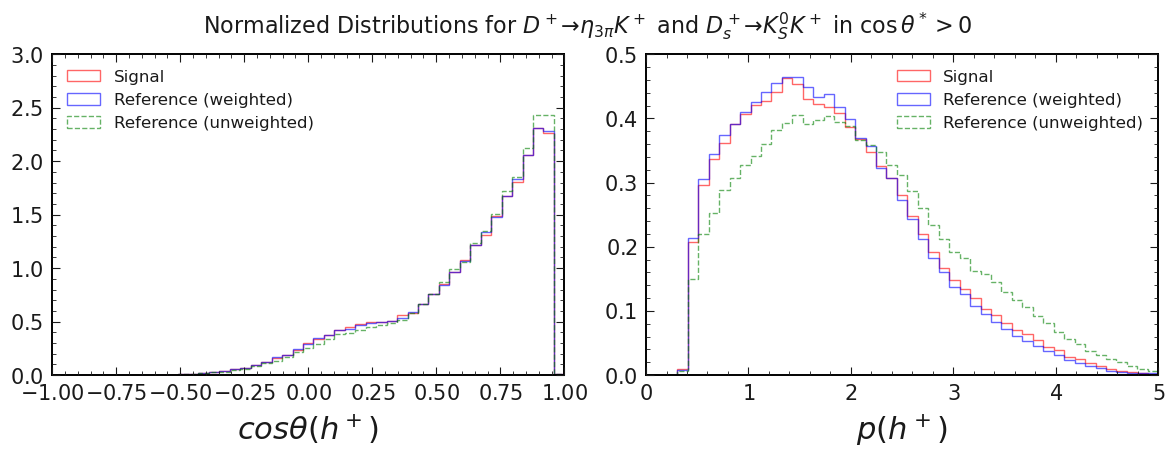

In [28]:

mode = r"$D^+ \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    # axes[idx].axvline(x=-0.55, color='k', linestyle='--', linewidth=1)

    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_pipipi_K_2_vars_reweighting_plus.pdf")
plt.show()

In [29]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi_cc/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가
N_signal = len(df_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = "0.77"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# # === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_minus.pkl'")
# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_K_minus.pkl'


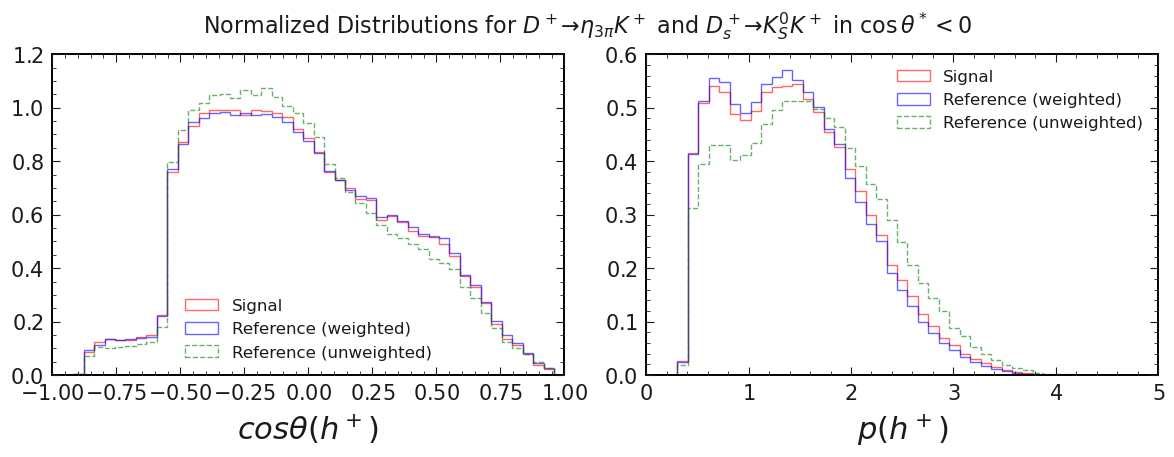

In [30]:

mode = r"$D^+ \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    # axes[idx].axvline(x=-0.55, color='k', linestyle='--', linewidth=1)

    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_pipipi_K_2_vars_reweighting_minus.pdf")
plt.show()

In [31]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = "0.86"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)
# === Train XGBoost ===
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_plus.pkl'")

# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_K_plus.pkl'


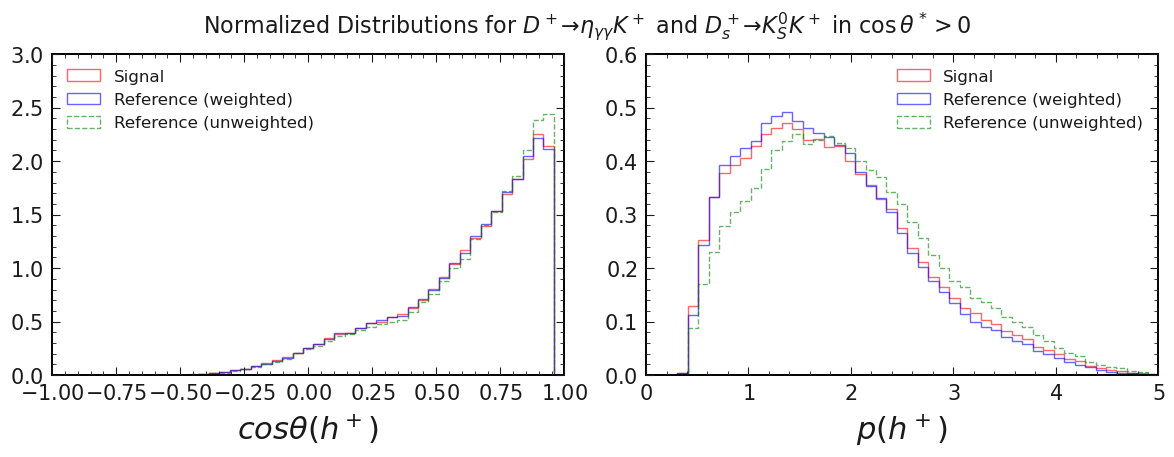

In [32]:

mode = r"$D^+ \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for idx, var in enumerate(variables):
#     bins = bins_dict[var]
#     axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
#     # axes[idx].set_title(f'Normalized Distribution')
#     axes[idx].set_title(f'{mode}')
#     axes[idx].set_xlim(bins[0], bins[-1])
#     axes[idx].set_xlabel(f'{var_info[var]}')
#     axes[idx].legend(loc=legend_loc[var])

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_gg_K_2_vars_reweighting_plus.pdf")
plt.show()

In [33]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = "0.86"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)
# === Train XGBoost ===
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_minus.pkl'")

# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_K_minus.pkl'


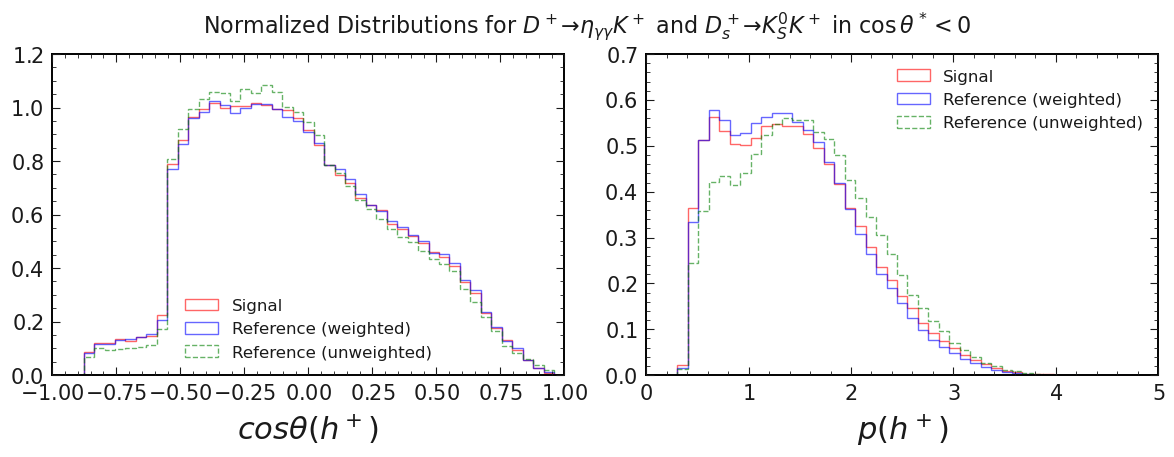

In [34]:

mode = r"$D^+ \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for idx, var in enumerate(variables):
#     bins = bins_dict[var]
#     axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
#     # axes[idx].set_title(f'Normalized Distribution')
#     axes[idx].set_title(f'{mode}')
#     axes[idx].set_xlim(bins[0], bins[-1])
#     axes[idx].set_xlabel(f'{var_info[var]}')
#     axes[idx].legend(loc=legend_loc[var])

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_gg_K_2_vars_reweighting_minus.pdf")
plt.show()

In [35]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi_cc/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = "0.77"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# # === Train-test split ===
# X_train, X_test, y_train, y_test = train_test_split(
#     combined_df[variables], combined_df['label'], combined_df['ds_weight'], test_size=0.3, random_state=42
# )

# # === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
# model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_pipipi_K_plus.pkl'


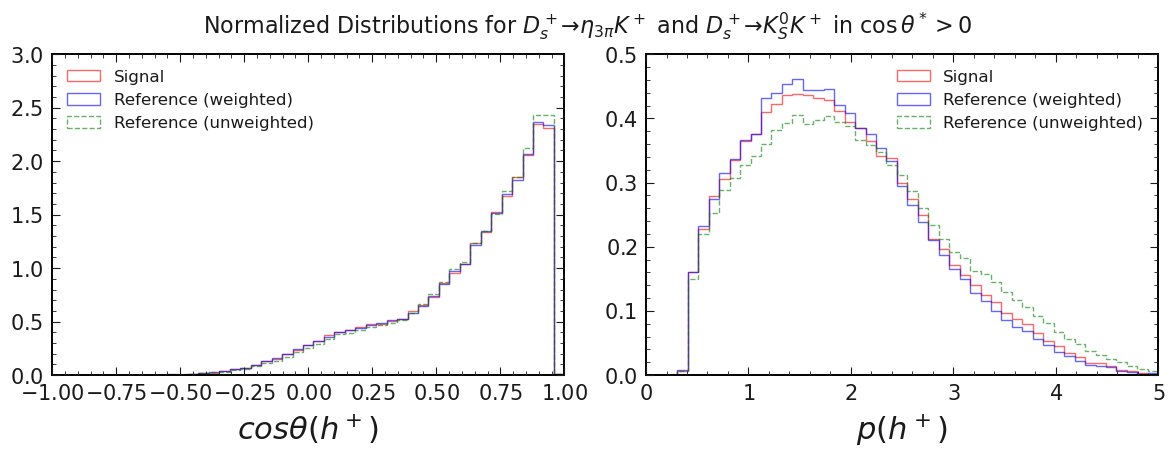

In [36]:

mode = r"$D^+_s \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_pipipi_K_2_vars_reweighting_plus.pdf")
plt.show()

In [37]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi_cc/260107_loose_v7_less_vars_ntuple/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = "0.77"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# # === Train-test split ===
# X_train, X_test, y_train, y_test = train_test_split(
#     combined_df[variables], combined_df['label'], combined_df['ds_weight'], test_size=0.3, random_state=42
# )

# # === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
# model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_pipipi_K_minus.pkl'


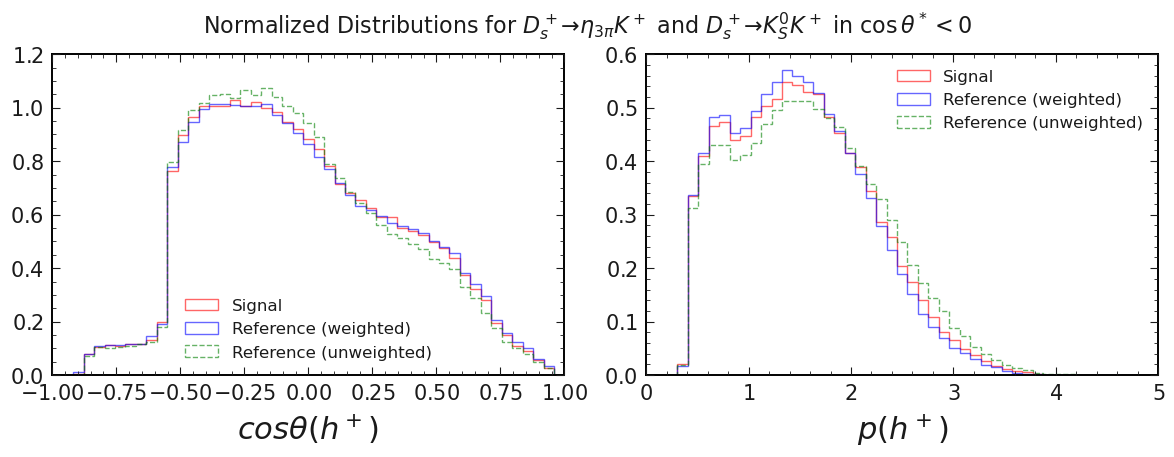

In [38]:

mode = r"$D^+_s \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_pipipi_K_2_vars_reweighting_minus.pdf")
plt.show()

In [39]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = "0.86"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_gg_K_plus.pkl'


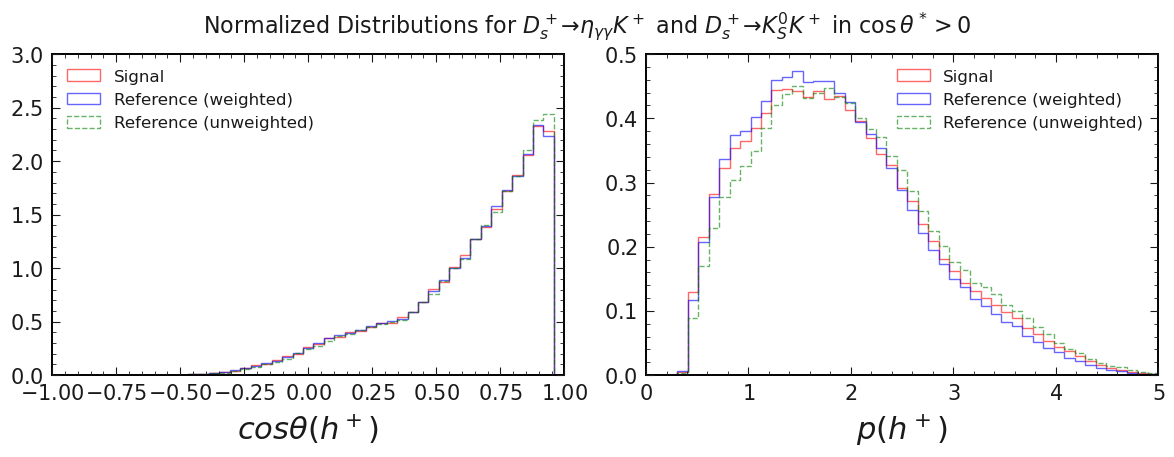

In [40]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_gg_K_2_vars_reweighting_plus.pdf")
plt.show()

In [41]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/260107_loose_v7_less_vars_ntuple/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_260109"
cm_elements = ["MC_KsHp_e7_18_4S_v3", "MC_KsHp_e20_b26_v1", "MC_KsHp_e20_e26_4S_v2", "MC_KsHp_e21_5Sscan_v1", "MC_KsHp_mori_off_v1"]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = "0.86"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*BDT.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_gg_K_minus.pkl'


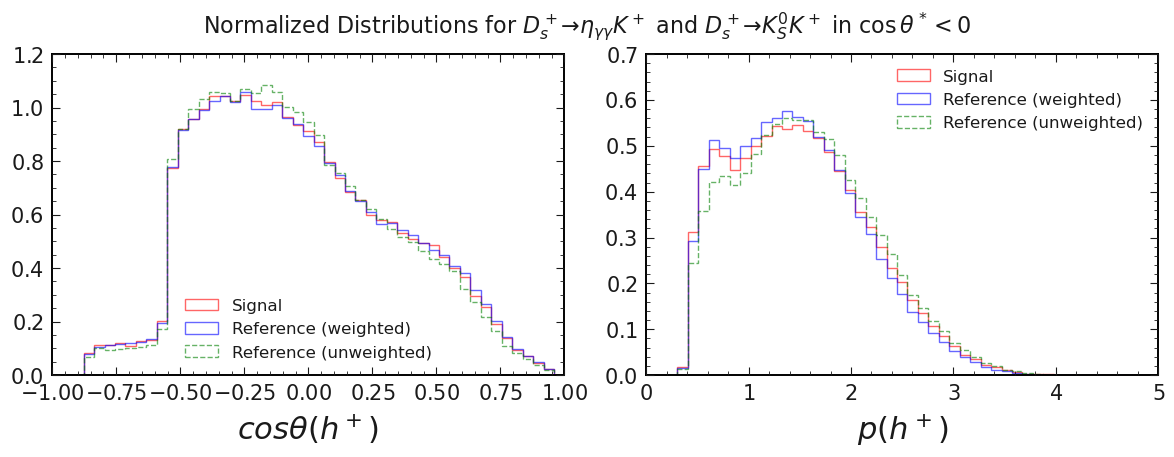

In [42]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_gg_K_2_vars_reweighting_minus.pdf")
plt.show()

In [23]:
# For some checks, not real
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = 0.91

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_gg_K_plus.pkl'


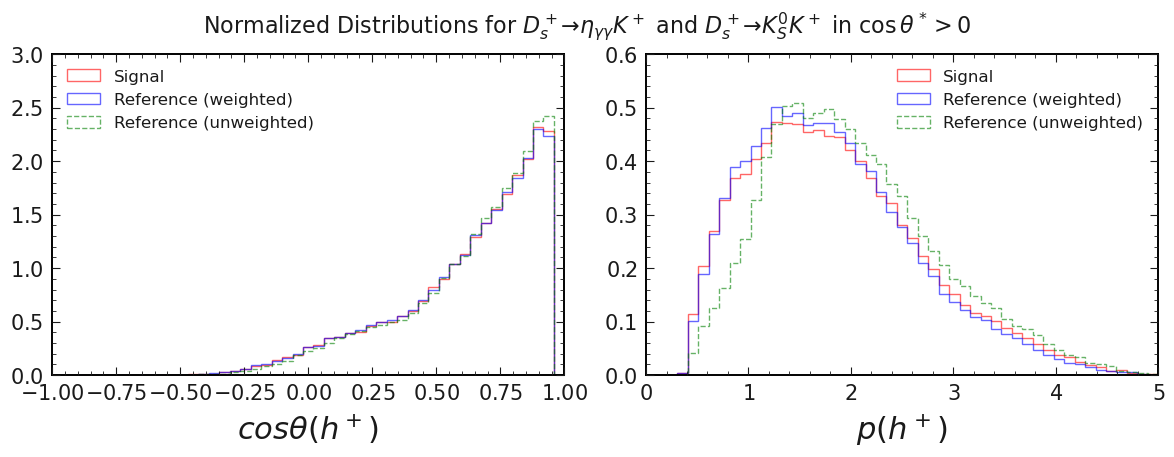

In [24]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_gg_K_2_vars_reweighting_plus.pdf")
plt.show()

In [37]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 & rank_Dp_chiProb==1'

# # === Signal and Reference file patterns ===
# signal_file = []
# signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
# signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
# signal_pattern = []
# for element in signal_file:
#     signal_pattern += glob.glob(element)

# # print(signal_pattern)
# df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K", cut_signal_Dp)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = "no_bdt"

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

In [38]:
df_ref

,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_mcPDG,Pip_genMotherID,etapip_Eta_genMotherID,Pip_genMotherPDG,etapip_Eta_isSignal,ds_weight,BDT,Dp_M
0,0.884728,0.867476,2.671339,-321.0,13.0,13.0,-431.0,1.0,0.681965,0.218628,1.968446
1,0.093449,-0.173404,1.442874,321.0,7.0,7.0,431.0,1.0,0.681965,0.348422,1.967396
2,0.092489,-0.026859,1.870280,321.0,3.0,3.0,431.0,1.0,0.989367,0.485763,1.969599
3,0.949135,0.880266,2.718548,-321.0,20.0,20.0,-431.0,1.0,0.681965,0.501473,1.969516
4,0.155497,0.892225,0.561088,-321.0,19.0,19.0,-431.0,1.0,0.806593,0.393176,1.964967
...,...,...,...,...,...,...,...,...,...,...,...
463156,0.262170,0.056161,0.887102,321.0,20.0,20.0,431.0,1.0,0.681965,0.854625,1.968317
463157,0.741363,0.453975,1.430610,321.0,8.0,8.0,431.0,1.0,1.139653,0.598632,1.977080
463158,0.715141,0.788406,3.163804,321.0,9.0,9.0,431.0,1.0,0.806593,0.257358,1.966344
463159,0.821067,0.913856,2.145787,321.0,24.0,24.0,431.0,1.0,0.755798,0.832842,1.972934


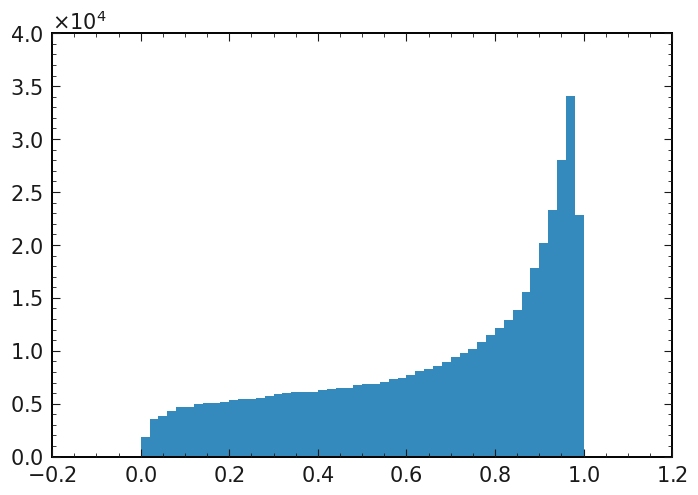

In [39]:
plt.hist(df_ref.BDT, bins=np.linspace(0,1,51));

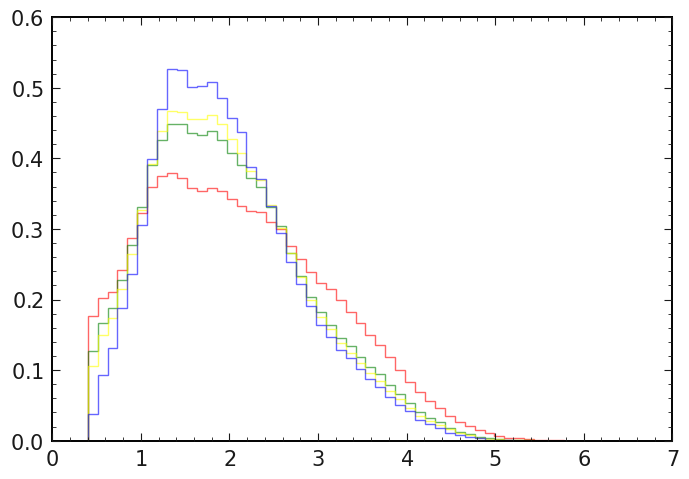

In [55]:
plt.hist(df_ref.Pip_p, bins=np.linspace(0.4,6,51), density=True, alpha=0.6,color='red',histtype='step');
plt.hist(df_ref.query('BDT>0.5').Pip_p, bins=np.linspace(0.4,6,51),density=True, alpha=0.6, color='green',histtype='step');
plt.hist(df_ref.query('BDT>0.7').Pip_p, bins=np.linspace(0.4,6,51),density=True, alpha=0.6, color='yellow',histtype='step');

plt.hist(df_ref.query('BDT>0.91').Pip_p, bins=np.linspace(0.4,6,51),density=True, alpha=0.6, color='blue',histtype='step');


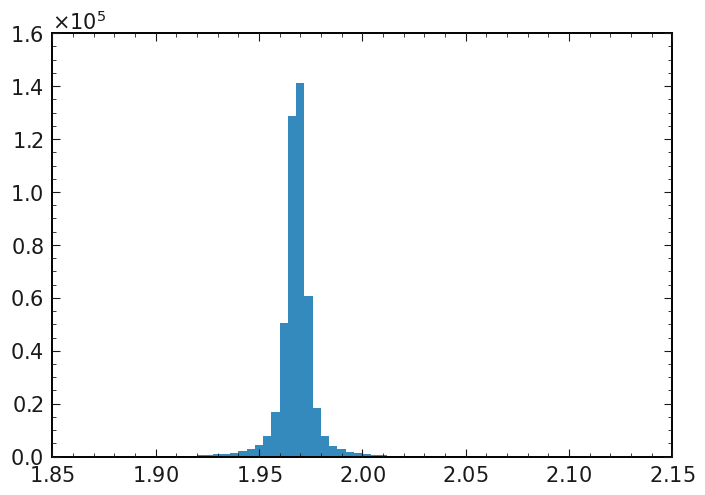

In [42]:
plt.hist(df_ref.Dp_M, bins=np.linspace(1.9,2.1,51));